In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
df = pd.read_csv(r"C:\Users\Charan\Desktop\JavaScript\Internship\TAKEITSMART\heart.csv")

print(df.head())
print(df.shape)

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
(1025, 14)


In [4]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [5]:
df.fillna(df.mean(), inplace=True)

In [6]:
print(df.duplicated().sum())

723


In [7]:
df.drop_duplicates(inplace=True)

In [8]:
print(df.skew())

age        -0.203743
sex        -0.786120
cp          0.493022
trestbps    0.716541
chol        1.147332
fbs         1.981201
restecg     0.169467
thalach    -0.532671
exang       0.737281
oldpeak     1.266173
slope      -0.503247
ca          1.295738
thal       -0.481232
target     -0.173691
dtype: float64


In [9]:
df['chol'] = np.log1p(df['chol'])

In [10]:
df['oldpeak'] = np.log1p(df['oldpeak'])
df['ca'] = np.log1p(df['ca'])

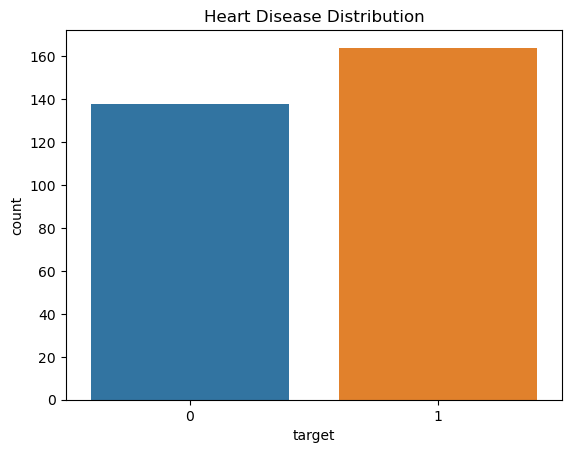

In [11]:
sns.countplot(x='target', data=df)
plt.title("Heart Disease Distribution")
plt.show()

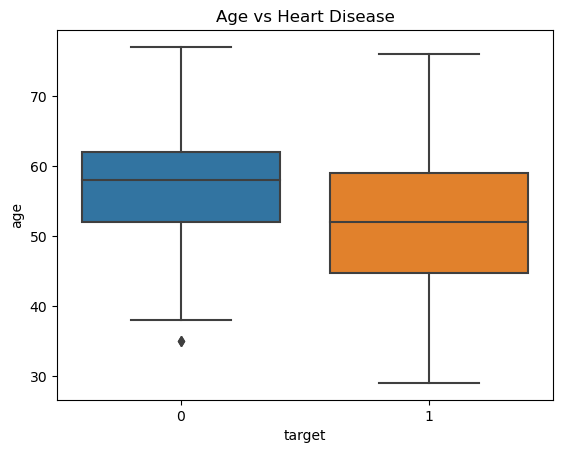

In [12]:
sns.boxplot(x='target', y='age', data=df)
plt.title("Age vs Heart Disease")
plt.show()

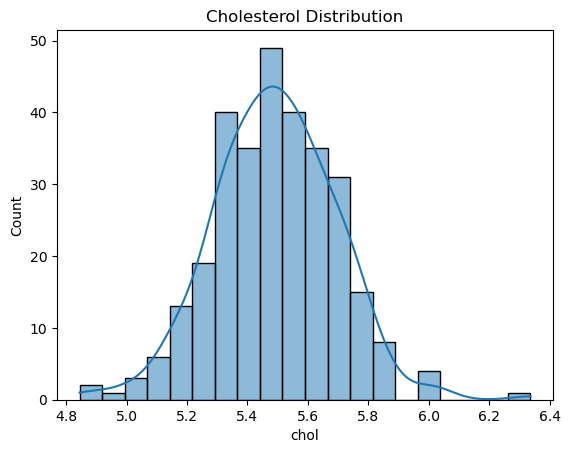

In [13]:
sns.histplot(df['chol'], bins=20, kde=True)
plt.title("Cholesterol Distribution")
plt.show()

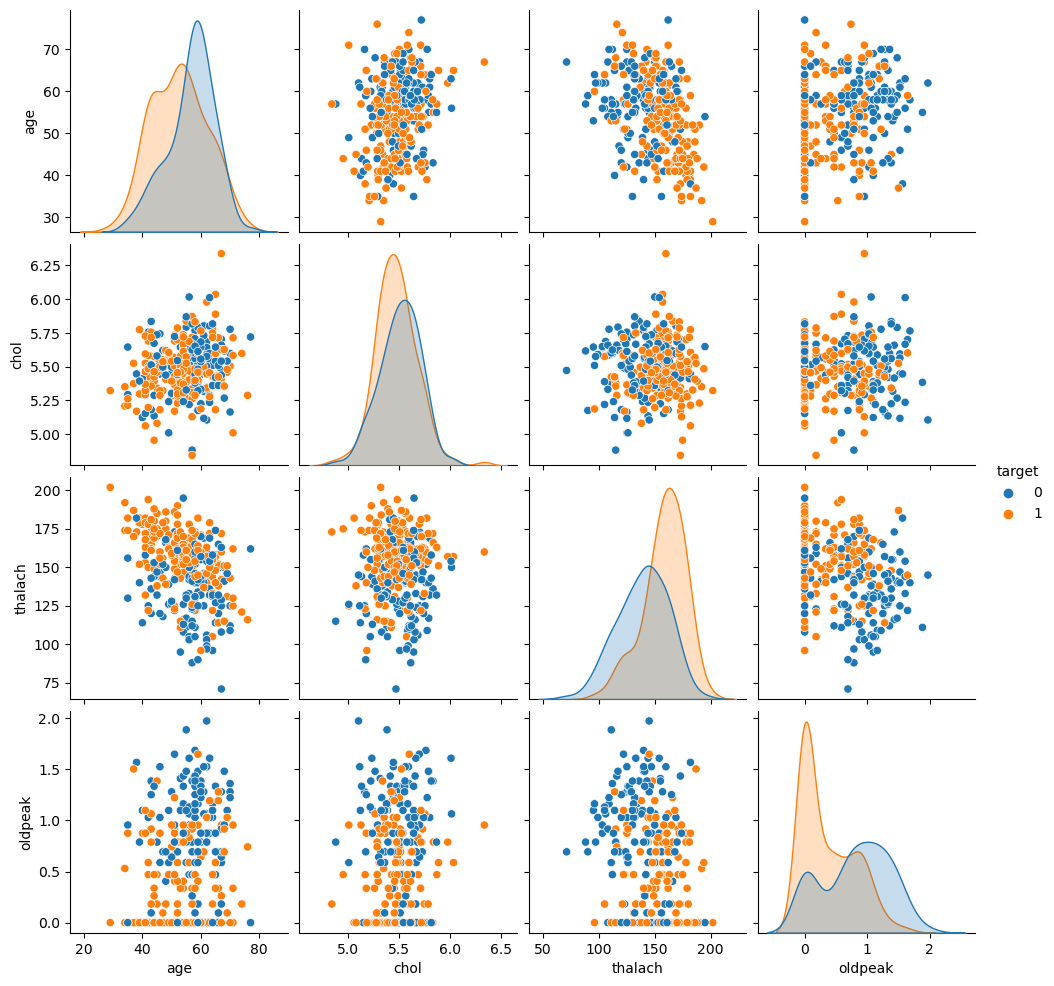

In [14]:
sns.pairplot(df[['age','chol','thalach','oldpeak','target']], hue='target')
plt.show()

In [15]:
X = df.drop('target', axis=1)
y = df['target']

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [19]:
y_pred = model.predict(X_test)

In [20]:
y_pred_class = (y_pred >= 0.5).astype(int)

In [21]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_class))

Accuracy: 0.7868852459016393


In [22]:
Q1 = df.loc[:,'chol'].quantile(0.25) 
Q3 = df.loc[:,'chol'].quantile(0.75) 
IQR = Q3-Q1
lower_limit = Q1-1.5*IQR
upper_limit = Q3+1.5*IQR



In [23]:
df[(df.loc[:,'chol']>upper_limit) | (df.loc[:,'chol']<lower_limit)]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
32,57,1,0,130,4.882802,0,1,115,1,0.788457,1,0.693147,3,0
101,57,1,2,150,4.844187,1,1,173,0,0.182322,2,0.693147,3,1
123,65,0,2,140,6.035481,1,0,157,0,0.587787,2,0.693147,2,1
158,67,0,2,115,6.336826,0,0,160,0,0.955511,1,0.000000,3,1
179,56,0,0,134,6.016157,0,0,150,1,1.064711,1,1.098612,3,0
733,44,0,2,108,4.955827,0,1,175,0,0.470004,1,0.000000,2,1


In [24]:
len(df[(df.loc[:,'chol']>upper_limit) | (df.loc[:,'chol']<lower_limit)])/len(df)*100

1.9867549668874174

In [25]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [26]:
Q1 = df.loc[:,'oldpeak'].quantile(0.25) 
Q3 = df.loc[:,'oldpeak'].quantile(0.75) 
IQR = Q3-Q1
lower_limit = Q1-1.5*IQR
upper_limit = Q3+1.5*IQR



In [27]:
df[(df.loc[:,'oldpeak']>upper_limit) | (df.loc[:,'oldpeak']<lower_limit)]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target


In [28]:
len(df[(df.loc[:,'oldpeak']>upper_limit) | (df.loc[:,'oldpeak']<lower_limit)])/len(df)*100

0.0

In [29]:
mean_val = df.loc[:,'restecg'].mean()
std_val = df.loc[:,'restecg'].std()
upper_limit = mean_val+3*std_val
lower_limit = mean_val+3*std_val

In [30]:
df[(df.loc[:,'restecg']<lower_limit)|(df.loc[:,'restecg']>upper_limit)]


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,5.361292,0,1,168,0,0.693147,2,1.098612,3,0
1,53,1,0,140,5.318120,1,0,155,1,1.410987,0,0.000000,3,0
2,70,1,0,145,5.164786,0,1,125,1,1.280934,0,0.000000,3,0
3,61,1,0,148,5.318120,0,1,161,0,0.000000,2,0.693147,3,0
4,62,0,0,138,5.686975,1,1,106,0,1.064711,1,1.386294,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,68,0,2,120,5.356586,0,0,115,0,0.916291,1,0.000000,2,1
733,44,0,2,108,4.955827,0,1,175,0,0.470004,1,0.000000,2,1
739,52,1,0,128,5.545177,0,1,161,1,0.000000,2,0.693147,3,0
843,59,1,3,160,5.613128,0,0,125,0,0.000000,2,0.000000,2,0


In [31]:
len(df[(df.loc[:,'restecg']<lower_limit)|(df.loc[:,'restecg']>upper_limit)])/len(df)*100

100.0

In [32]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,5.361292,0,1,168,0,0.693147,2,1.098612,3,0
1,53,1,0,140,5.318120,1,0,155,1,1.410987,0,0.000000,3,0
2,70,1,0,145,5.164786,0,1,125,1,1.280934,0,0.000000,3,0
3,61,1,0,148,5.318120,0,1,161,0,0.000000,2,0.693147,3,0
4,62,0,0,138,5.686975,1,1,106,0,1.064711,1,1.386294,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,68,0,2,120,5.356586,0,0,115,0,0.916291,1,0.000000,2,1
733,44,0,2,108,4.955827,0,1,175,0,0.470004,1,0.000000,2,1
739,52,1,0,128,5.545177,0,1,161,1,0.000000,2,0.693147,3,0
843,59,1,3,160,5.613128,0,0,125,0,0.000000,2,0.000000,2,0


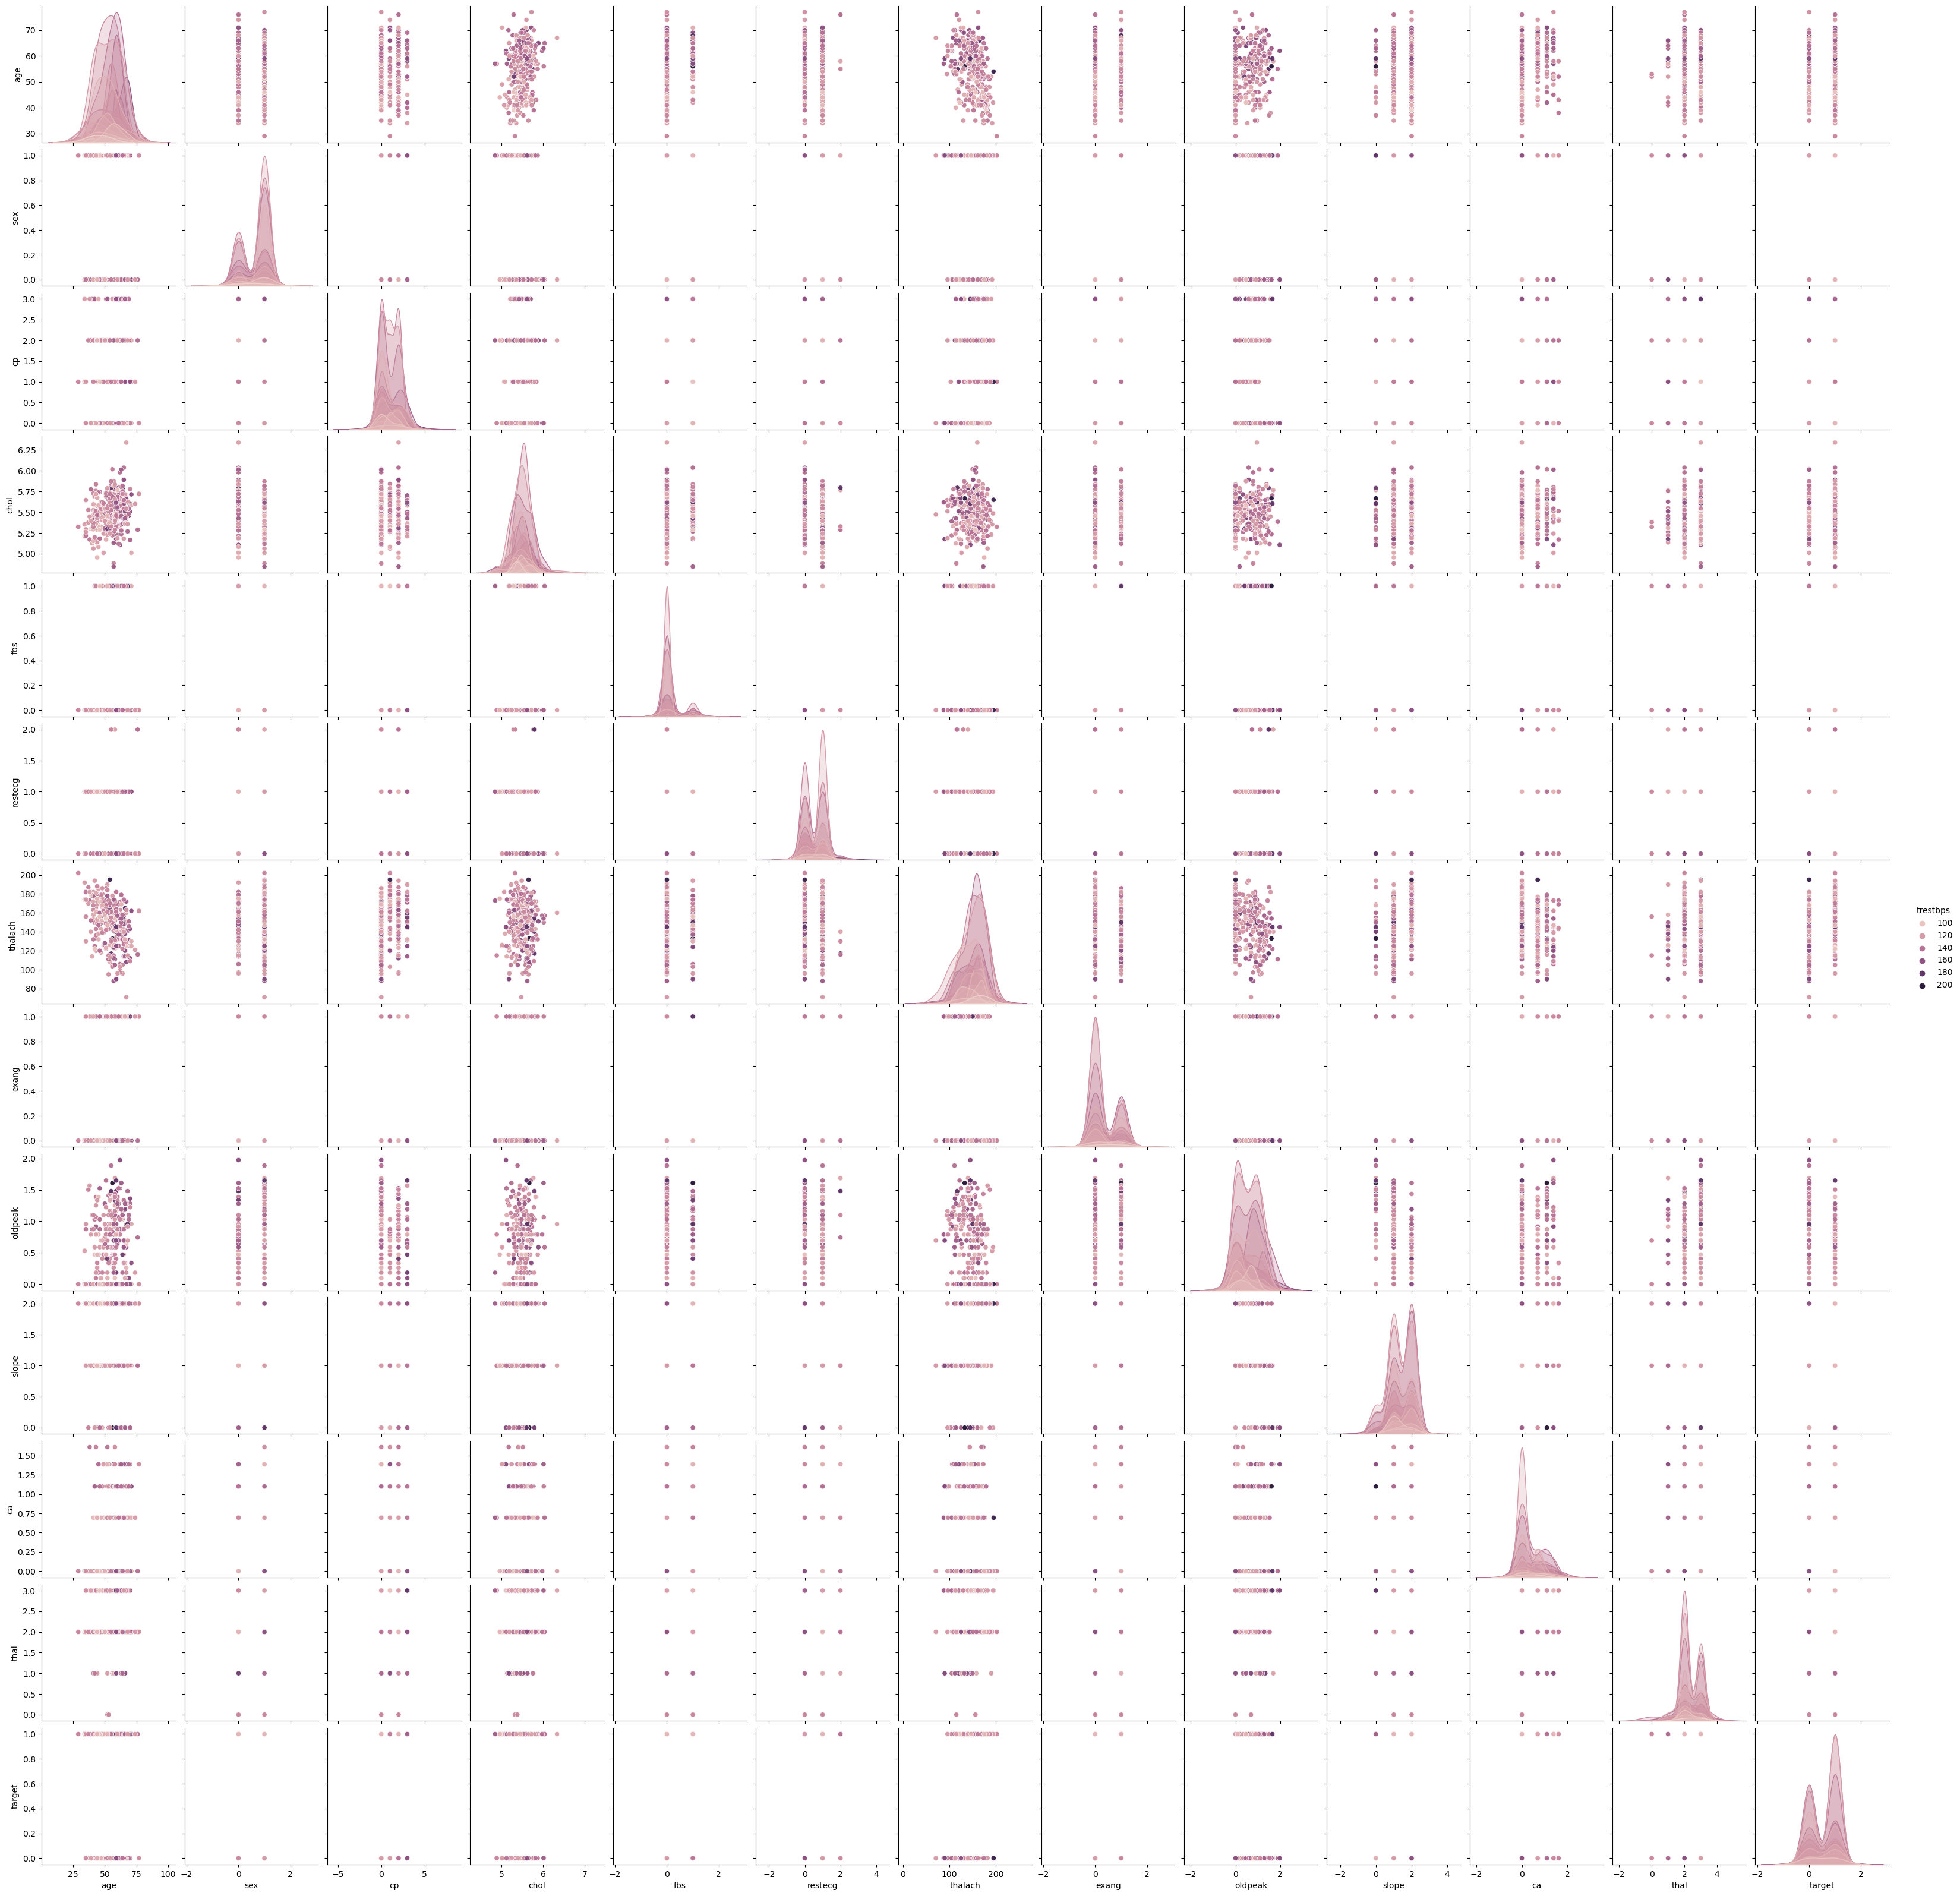

In [33]:
sns.pairplot(df,hue='trestbps')

In [34]:
x = df.drop(columns = ['trestbps'])
y = df.loc[:,'trestbps']
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

In [35]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

C:\Users\Public\python\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [67]:
model.coef_

array([  0.7736104 ,  -5.21889875,   1.11772687,  -1.09481427,
        16.92407592,  -6.55116043,   0.11631332,   0.30262432,
       -12.42460418, -13.1292899 ,  -8.51865914,   4.87124984,
       -21.93052533])

In [37]:
model.intercept_

array([-1.09986735e-03,  6.12901001e-04,  2.40182953e-03,  8.49663760e-04,
       -1.67549593e-03, -2.01527245e-03, -4.28214279e-03,  2.71107093e-02,
        5.68191690e-03, -1.69443155e-04, -6.83006906e-03, -2.79124915e-03,
        2.90602782e-04,  2.07667849e-02, -3.24060940e-03,  5.95162242e-03,
       -3.43662552e-03, -8.06863393e-03,  2.98717910e-03, -5.70367134e-04,
        1.03601403e-02,  2.76375395e-03, -3.98493849e-03, -4.64184909e-03,
        1.96734063e-03,  1.57064414e-03, -1.46370543e-02,  5.57630072e-03,
        4.24544491e-04, -7.17728647e-03, -5.69487682e-05,  4.31353288e-05,
       -4.65140874e-03, -2.69689570e-03, -6.94019410e-03,  5.54995735e-03,
        1.81928930e-03, -3.89342138e-03, -6.75252819e-04, -4.37519451e-03,
       -3.77930793e-03, -6.00315788e-03,  9.64370205e-04])

In [44]:
from sklearn.metrics import accuracy_score,confusion_matrix ,precision_score , f1_score

In [45]:
confusion_matrix(y_test,y_pred)

array([[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 3, 0, 0, 0, 0, 0,
        1, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0],
       [0, 0, 0, 0, 

In [46]:
accuracy_score(y_test,y_pred)

0.06557377049180328

In [54]:
# precision_score(y_test,y_pred)

In [53]:
# f1_score(y_test,y_pred)

In [56]:
!pip install imbalanced-learn

     -------------------------------------- 258.3/258.3 kB 1.6 MB/s eta 0:00:00
     -------------------------------------- 309.1/309.1 kB 2.7 MB/s eta 0:00:00
  Attempting uninstall: joblib
    Found existing installation: joblib 1.1.0
    Uninstalling joblib-1.1.0:
      Successfully uninstalled joblib-1.1.0


In [64]:
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=42)
x_sampled, y_sampled = ros.fit_resample(x_train, y_train)

In [65]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_sampled, y_sampled)

LinearRegression()

In [66]:
model.coef_

array([  0.7736104 ,  -5.21889875,   1.11772687,  -1.09481427,
        16.92407592,  -6.55116043,   0.11631332,   0.30262432,
       -12.42460418, -13.1292899 ,  -8.51865914,   4.87124984,
       -21.93052533])

In [69]:
f1_score(y_test, y_pred, average='weighted')

0.04074286369368337

In [70]:
confusion_matrix(y_test,y_pred)

array([[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 3, 0, 0, 0, 0, 0,
        1, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0],
       [0, 0, 0, 0, 

In [ ]:
presicion_